# Feature sifting — which pruning rule finds the good features?

The task (`phd/jax_core/tasks/feature_sifting.py`) gives a linear learner 20 candidate features, each a
noisy view of one of 10 true features, and lets it mark slots for replacement; the target is a ±1
weighted sum of the true features. Every method below is Autostep online linear regression and differs
only in **when it throws a feature away**.

1. **Autostep** — never prunes; the no-search baseline.
2. **Autostep + G&T** — every `prune_period` steps, drop the lowest-magnitude weight.
3. **Autostep + prune on w crossing 0** — a dead feature's weight jitters around 0 and crosses it
   constantly; a useful one settles at its own w\* and stops.
4. **Autostep + both rules** — prune on a weight zero-crossing, *or* when the Autostep gradient
   trace `h` crosses zero while `|w|` is in the bottom half. `h` flipping sign says the step-size
   overshot, and the median gate keeps a clearly-useful weight from being thrown away for wobbling.

The step-sizes are fixed (initial 2⁻¹⁴, meta 2⁻⁵) and the only swept hyperparameter is method 2's
prune period.

In [1]:
import os
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import seaborn as sns

from phd.jax_core.optimizers.idbd import IDBDState, optax_idbd
from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.utils import tree_replace
from phd.research_utils.analysis.analysis_utils import get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')      # run caches
os.makedirs(DATA_DIR, exist_ok=True)
CACHE_PREFIX = 'pruning_rules'

# --- Task ---
N_TARGET_FEATURES = 10
N_LEARNER_FEATURES = 20
TARGET_NOISE_STD = 0.0

# --- Learner: fixed everywhere, never swept ---
INIT_LR = 2.0 ** -14             # initial step-size
META_LR = 2.0 ** -5              # meta step-size

# --- Training and recording ---
NUM_STEPS = 200_000
N_SEEDS = 30                     # vmapped into one scan
N_LOG_POINTS = 250               # binned points per curve
FINAL_FRACTION = 0.05            # last 5% of steps define the final loss
BASE_SEED = 0
OVERWRITE = False                # True recomputes every run and rewrites its cache

PRUNE_PERIODS = [2 ** e for e in range(4, 13, 2)]   # the one sweep: G&T's prune period

# Loss of the trivial predictor (always predicts 0): E[y^2]. Target weights are +-1 and target
# features are uniform[-1, 1] (variance 1/3), so anything that learns beats this.
BASELINE_LOSS = N_TARGET_FEATURES / 3.0 + TARGET_NOISE_STD ** 2
print('baseline loss:', round(BASELINE_LOSS, 4))

baseline loss: 3.3333


In [3]:
def linear_loss_and_grads(w, x, y):
    """Squared-error loss of the linear prediction, and the LMS gradient `delta * x`.

    The exact gradient up to the constant factor 2, which is folded into the step-size.
    """
    error = jnp.sum(w * x[None, :]) - y
    return error ** 2, error * x[None, :]


def reset_idbd_state(opt_state, prune_mask):
    """Put a pruned slot's Autostep state back to initial: step-size to `INIT_LR`, h and v to 0."""
    m = prune_mask[None, :]      # broadcast over the single output row
    return IDBDState(
        init_beta=opt_state.init_beta,
        beta=jnp.where(m, opt_state.init_beta, opt_state.beta),
        h=jnp.where(m, 0.0, opt_state.h),
        v=jnp.where(m, 0.0, opt_state.v),
    )


def make_optimizer():
    """The Autostep optimizer every method uses."""
    return optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True)


def loss_floor(task):
    """Quality of the feature set the method currently holds: for each of the `N_TARGET_FEATURES`
    targets, the lowest noise coefficient among the slots pointing at it (1.0 if uncovered), summed.
    A good sifter keeps low-noise candidates and drives this down."""
    def best_for_target(idx):
        here = task.learner_feature_idxs == idx
        return jnp.where(here.any(), jnp.min(jnp.where(here, task.noise_coefficients, 1.0)), 1.0)
    return jnp.sum(jax.vmap(best_for_target)(jnp.arange(N_TARGET_FEATURES)))

In [4]:
def run(method_cls, n_seeds=N_SEEDS, **hparams):
    """Run `n_seeds` seeds of a method, batched into one jitted scan.

    Each step records the squared error, the loss floor of the current feature set, and how many
    slots the method pruned. The learner is deterministic given the task, so a seed is just a task.
    """
    def one_seed(task_key):
        task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD,
                                  key=task_key)
        state = method_cls.init(**hparams)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)     # the task regenerates pruned slots
            state, loss = state.step(x, jnp.squeeze(y))
            return (task, state), (loss, loss_floor(task), jnp.sum(state.prune_mask))

        _, out = jax.lax.scan(scan_step, (task, state), length=NUM_STEPS)
        return out

    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    loss, floor, pruned = jax.jit(jax.vmap(one_seed))(keys)

    mean, std = binned(loss)
    return {'steps': np.arange(1, N_LOG_POINTS + 1) * (NUM_STEPS // N_LOG_POINTS),
            'loss': mean, 'loss_std': std, 'floor': binned(floor)[0],
            'prune_rate': binned(pruned)[0],
            'final_loss': np.asarray(loss)[:, -int(FINAL_FRACTION * NUM_STEPS):].mean()}


def binned(arr, n_points=N_LOG_POINTS):
    """Bin an (n_seeds, NUM_STEPS) record into `n_points` window means: (mean, std) over seeds."""
    arr = np.asarray(arr, dtype=np.float32)
    width = arr.shape[1] // n_points
    b = arr[:, :width * n_points].reshape(arr.shape[0], n_points, width).mean(2)
    return b.mean(0), b.std(0)


def cached(name, fn):
    """Run `fn` once, caching every array it returns in `data/<name>.npz`.

    Set `OVERWRITE = True` in the configuration cell to ignore the caches and recompute everything.
    """
    path = os.path.join(DATA_DIR, f'{CACHE_PREFIX}_{name}.npz')
    if OVERWRITE or not os.path.exists(path):
        print(f'running {name} ...')
        np.savez_compressed(path, **{k: np.asarray(v) for k, v in fn().items()})
    with np.load(path) as z:
        return {k: z[k] for k in z.files}

## The four methods

One class each, and the class is the whole method: predict, learn, decide what to throw away.

In [5]:
class Autostep(eqx.Module):
    """Autostep online linear regression on the fixed initial feature set. Never prunes."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer, w = make_optimizer(), jnp.zeros((1, N_LEARNER_FEATURES))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(N_LEARNER_FEATURES, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        # Autostep consumes the loss gradient and the prediction gradient (= x).
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)
        return tree_replace(self, w=w, opt_state=opt_state), loss    # prune_mask stays all-False

In [6]:
class AutostepGT(eqx.Module):
    """Autostep + generate & test: every `prune_period` steps, prune the single lowest-magnitude
    weight (utility = |w|). Like CBP, but the utility is the weight magnitude and pruning fires on a
    fixed clock."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    prune_period: int = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    step_idx: jax.Array
    prune_mask: jax.Array

    @classmethod
    def init(cls, prune_period):
        optimizer, w = make_optimizer(), jnp.zeros((1, N_LEARNER_FEATURES))
        return cls(optimizer=optimizer, prune_period=int(prune_period), w=w,
                   opt_state=optimizer.init(w), step_idx=jnp.array(0),
                   prune_mask=jnp.zeros(N_LEARNER_FEATURES, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        step_idx = self.step_idx + 1
        due = (step_idx % self.prune_period) == 0
        prune_mask = due & (jnp.arange(N_LEARNER_FEATURES) == jnp.argmin(jnp.abs(w[0])))

        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)
        return tree_replace(self, w=w, opt_state=opt_state, step_idx=step_idx,
                            prune_mask=prune_mask), loss

In [7]:
class AutostepWCross(eqx.Module):
    """Autostep, pruning a feature the step its weight crosses zero.

    A dead feature has no gradient holding its weight anywhere, so it jitters around zero and crosses
    it constantly; a useful feature settles at its own w* and stops crossing. No clock, no threshold,
    nothing to estimate. A fresh feature sits at exactly w = 0, so the product is 0 and it is never
    pruned on arrival."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer, w = make_optimizer(), jnp.zeros((1, N_LEARNER_FEATURES))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(N_LEARNER_FEATURES, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        prune_mask = (self.w * w < 0.0)[0]           # weight changed sign this step
        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss

In [8]:
class AutostepWOrHCross(eqx.Module):
    """Autostep with both kill rules: prune a feature when its weight crosses zero, or when its
    gradient trace `h` crosses zero while its weight magnitude is in the bottom half.

    The two catch different states. A weight crossing zero means nothing is holding the feature
    anywhere. `h` flipping sign is the classic signal that a step-size overshot, and it fires whether
    or not the weight happens to be near zero — so the median gate carries the "is this feature
    actually doing anything?" part, keeping a large, clearly-useful weight from being thrown away
    just for wobbling."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jax.Array
    opt_state: optax.OptState
    prune_mask: jax.Array

    @classmethod
    def init(cls):
        optimizer, w = make_optimizer(), jnp.zeros((1, N_LEARNER_FEATURES))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w),
                   prune_mask=jnp.zeros(N_LEARNER_FEATURES, dtype=bool))

    def step(self, x, y):
        loss, loss_grads = linear_loss_and_grads(self.w, x, y)
        h_prev = self.opt_state.h
        updates, opt_state = self.optimizer.update((loss_grads, x[None, :]), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        w_cross = (self.w * w < 0.0)[0]              # weight changed sign this step
        h_cross = (h_prev * opt_state.h < 0.0)[0]    # h changed sign this step
        util = jnp.abs(w[0])
        prune_mask = w_cross | (h_cross & (util < jnp.median(util)))

        w = jnp.where(prune_mask[None, :], 0.0, w)
        opt_state = reset_idbd_state(opt_state, prune_mask)
        return tree_replace(self, w=w, opt_state=opt_state, prune_mask=prune_mask), loss

In [9]:
def plot_losses(runs, title, ax=None):
    """Learning curves, mean +- 2 standard errors over seeds, on a log axis."""
    ax = ax or plt.gca()
    for (label, res), color in zip(runs.items(), get_color_palette(n=len(runs))):
        sem = res['loss_std'] / np.sqrt(N_SEEDS)
        ax.plot(res['steps'], res['loss'], color=color, label=label)
        ax.fill_between(res['steps'], res['loss'] - 2 * sem, res['loss'] + 2 * sem,
                        color=color, alpha=0.2)
    ax.axhline(BASELINE_LOSS, ls='--', c='gray', lw=1, label='predict 0')
    ax.set_yscale('log')
    ax.set_xlabel('step')
    ax.set_ylabel('squared error')
    ax.set_title(title)
    ax.grid(alpha=0.4, which='both')
    ax.legend(fontsize=8)


def summary_table(runs):
    """Final loss, final feature-set floor, and how often each method prunes."""
    tail = max(1, int(FINAL_FRACTION * N_LOG_POINTS))
    return pd.DataFrame([{
        'method': label,
        'final loss': float(res['final_loss']),
        'final floor': float(res['floor'][-tail:].mean()),
        'prunes / 1k steps': float(res['prune_rate'].mean()) * 1000,
    } for label, res in runs.items()])

## G&T's prune period

The only sweep. Too fast and useful features are thrown away before they prove themselves; too slow
and the search never finishes.

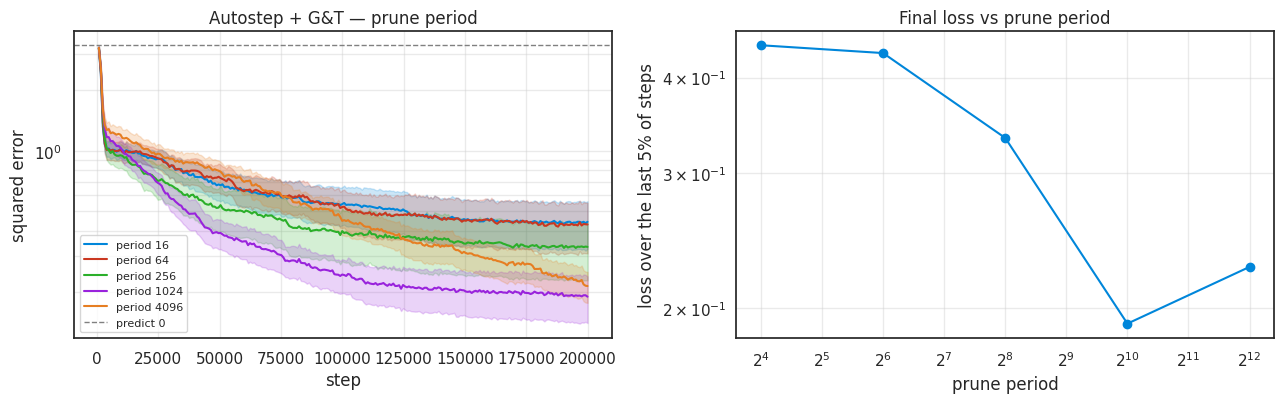

best prune period: 1024


In [10]:
GT_RUNS = {f'period {p}': cached(f'gt_{p}', lambda p=p: run(AutostepGT, prune_period=p))
           for p in PRUNE_PERIODS}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_losses(GT_RUNS, 'Autostep + G&T — prune period', ax=axes[0])
axes[1].plot(PRUNE_PERIODS, [GT_RUNS[f'period {p}']['final_loss'] for p in PRUNE_PERIODS],
             marker='o', color=get_color_palette(n=1)[0])
axes[1].set_xscale('log', base=2)
axes[1].set_yscale('log')
axes[1].set_xlabel('prune period')
axes[1].set_ylabel(f'loss over the last {FINAL_FRACTION:.0%} of steps')
axes[1].set_title('Final loss vs prune period')
axes[1].grid(alpha=0.4, which='both')
fig.tight_layout()
plt.show()

BEST_PERIOD = min(PRUNE_PERIODS, key=lambda p: GT_RUNS[f'period {p}']['final_loss'])
print('best prune period:', BEST_PERIOD)

## Comparison

G&T at its best prune period against the three others. The floor panel is the quality of the feature
set each method holds; the prune-rate panel is how much churn it takes to get there.

running w_or_h_cross ...


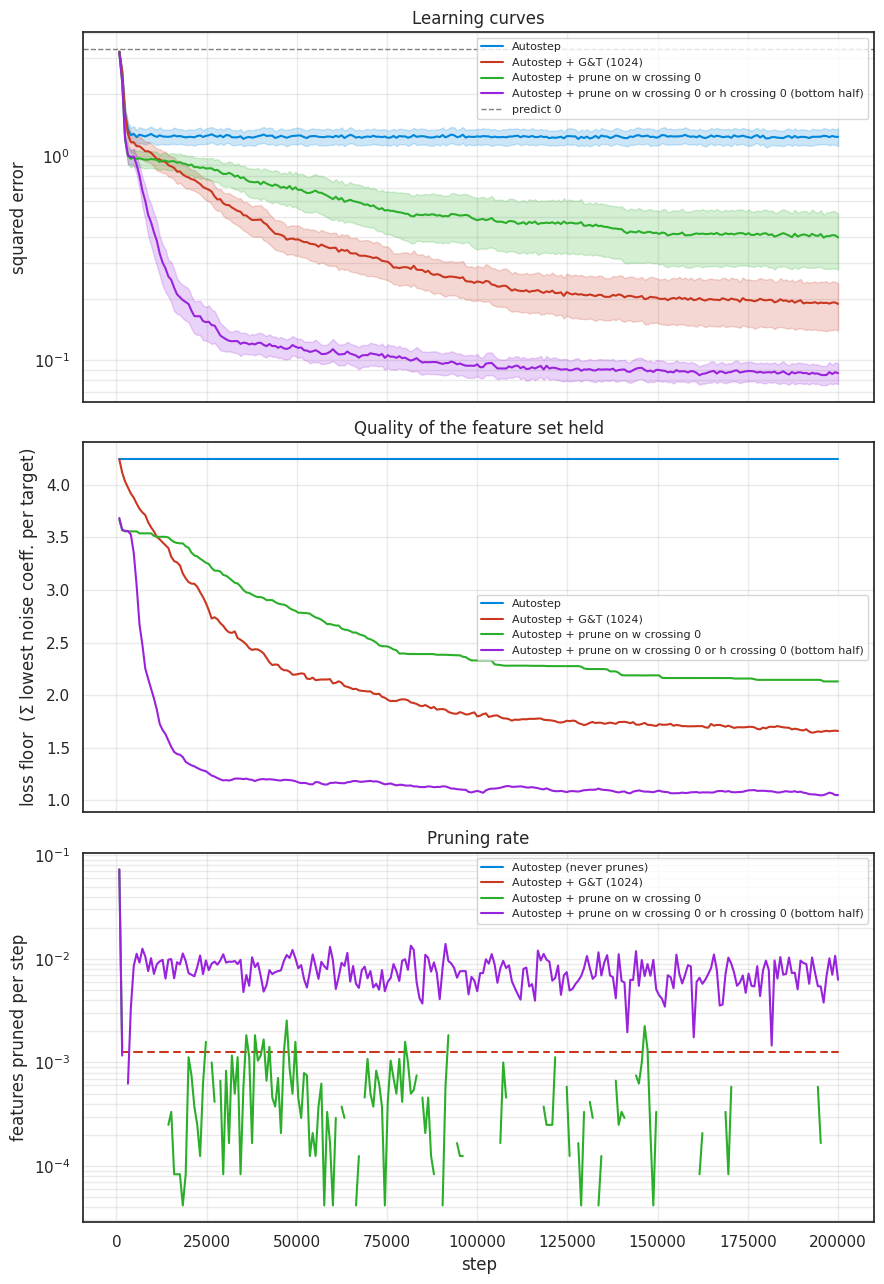

                                                        method  final loss  final floor  prunes / 1k steps
                                                      Autostep       1.242        4.243                  0
                                         Autostep + G&T (1024)      0.1909        1.656              0.975
                              Autostep + prune on w crossing 0      0.4075        2.137             0.5953
Autostep + prune on w crossing 0 or h crossing 0 (bottom half)     0.08615        1.057              7.878


In [11]:
RUNS = {
    'Autostep': cached('autostep', lambda: run(Autostep)),
    f'Autostep + G&T ({BEST_PERIOD})': GT_RUNS[f'period {BEST_PERIOD}'],
    'Autostep + prune on w crossing 0': cached('w_cross', lambda: run(AutostepWCross)),
    'Autostep + prune on w crossing 0 or h crossing 0 (bottom half)':
        cached('w_or_h_cross', lambda: run(AutostepWOrHCross)),
}

fig, axes = plt.subplots(3, 1, figsize=(9, 13), sharex=True)
plot_losses(RUNS, 'Learning curves', ax=axes[0])
for (label, res), color in zip(RUNS.items(), get_color_palette(n=len(RUNS))):
    axes[1].plot(res['steps'], res['floor'], color=color, label=label)
    rate = np.where(res['prune_rate'] > 0, res['prune_rate'], np.nan)
    axes[2].plot(res['steps'], rate, color=color,
                 label=label if np.isfinite(rate).any() else f'{label} (never prunes)')
axes[1].set(ylabel='loss floor  ($\\Sigma$ lowest noise coeff. per target)',
            title='Quality of the feature set held')
axes[2].set(xlabel='step', ylabel='features pruned per step', yscale='log',
            title='Pruning rate')
for ax in axes[1:]:
    ax.grid(alpha=0.4, which='both')
    ax.legend(fontsize=8)
for ax in axes[:2]:
    ax.set_xlabel('')            # shared x axis: only the bottom panel is labelled
fig.tight_layout()
plt.show()

print(summary_table(RUNS).to_string(index=False, float_format=lambda v: f'{v:.4g}'))